# Logistic Regression

## Imports

### Import data

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('../../data/model-ready.csv')
df.head()

,ISRC,Genre,Track,Album Name,Artist,All Time Rank,Track Score,Spotify Streams,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,AirPlay Spins,Pandora Streams,Pandora Track Stations,Shazam Counts,Explicit Track,Length,Releases,Registration Country,Followers,TikTok Views per Post,TikTok Impact,TikTok View-to-Like Ratio,TikTok Likes per Post,YouTube View-to-Like Ratio,Shazam Conversion Rate,Days Since Release,Label Prob,Label
0,QM24S2402528,Other,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,1,725.4,390470936,92,84274754,1713126,5767700,651565900,5332281936,40975,18004655,22931,2669262,0,155.1510,1,United States,847504.0,924.507505,0.000011,8.183795,112.968044,49.193524,0.000493,344,0.734589,1
1,USUG12400910,Rap,Not Like Us,Not Like Us,Kendrick Lamar,2,545.9,323703884,92,116347040,3486739,674700,35223547,208339025,40778,7780028,28444,1118279,1,274.1920,5,United States,38589324.0,308.787646,0.000003,5.914765,52.206158,33.368430,0.003444,336,0.721077,1
2,QZJ842400387,Other,i like the way you kiss me,I like the way you kiss me,Artemas,3,538.4,601309283,92,122599116,2228730,3025400,275154237,3369120610,74333,5022621,5639,5285340,0,143.1865,8,United States,1133424.0,1113.611625,0.000009,12.244480,90.948022,55.008485,0.001514,382,0.771418,1
3,USSM12209777,Other,Flowers,Flowers - Single,Miley Cyrus,4,444.9,2031280633,85,1096100899,10629796,7189811,1078757968,14603725994,1474799,190260277,203384,11822942,0,200.4530,30,United States,25620499.0,2031.169664,0.000002,13.537537,150.039802,103.115883,0.000753,814,0.799485,1
4,USAT22311371,Other,Lovin On Me,Lovin On Me,Jack Harlow,6,410.1,670665438,83,131148091,1392593,4202367,214943489,2938686633,522042,138529362,50982,4517131,1,138.4110,13,United States,4106706.0,699.293192,0.000005,13.671903,51.148183,94.175396,0.001471,512,0.758437,1


### Import modules

For Logistic Regression, we use scikit-learn's LogisticRegression classifier:
1. LogisticRegression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression

To interpret results, we use scikit-learn's ConfusionMatrixDisplay and matplotlib's pyplot.barh:
1. ConfusionMatrixDisplay: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html
2. pyplot.barh: https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.barh.html

## Data Prep

### Custom functions to reduce code repetition

See file at `./custom_data_prep.py` for the code.

In [2]:
from custom_data_prep import (
    my_corr_plotter, 
    my_count_binner, my_count_vectorizer, my_bin_plotter
)

### Feature selection

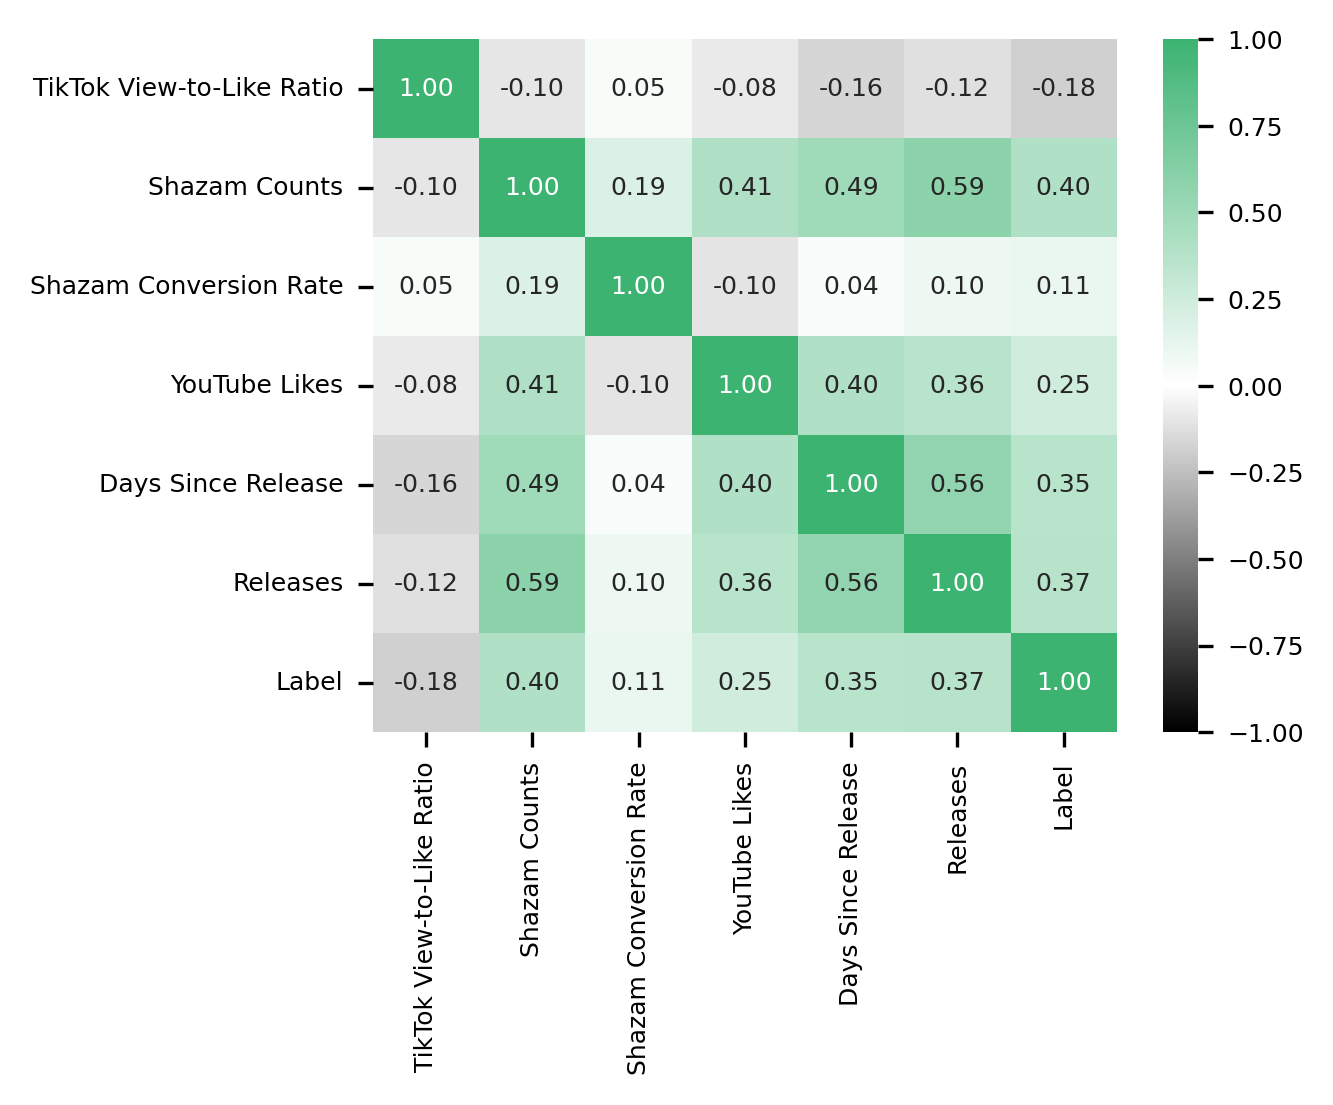

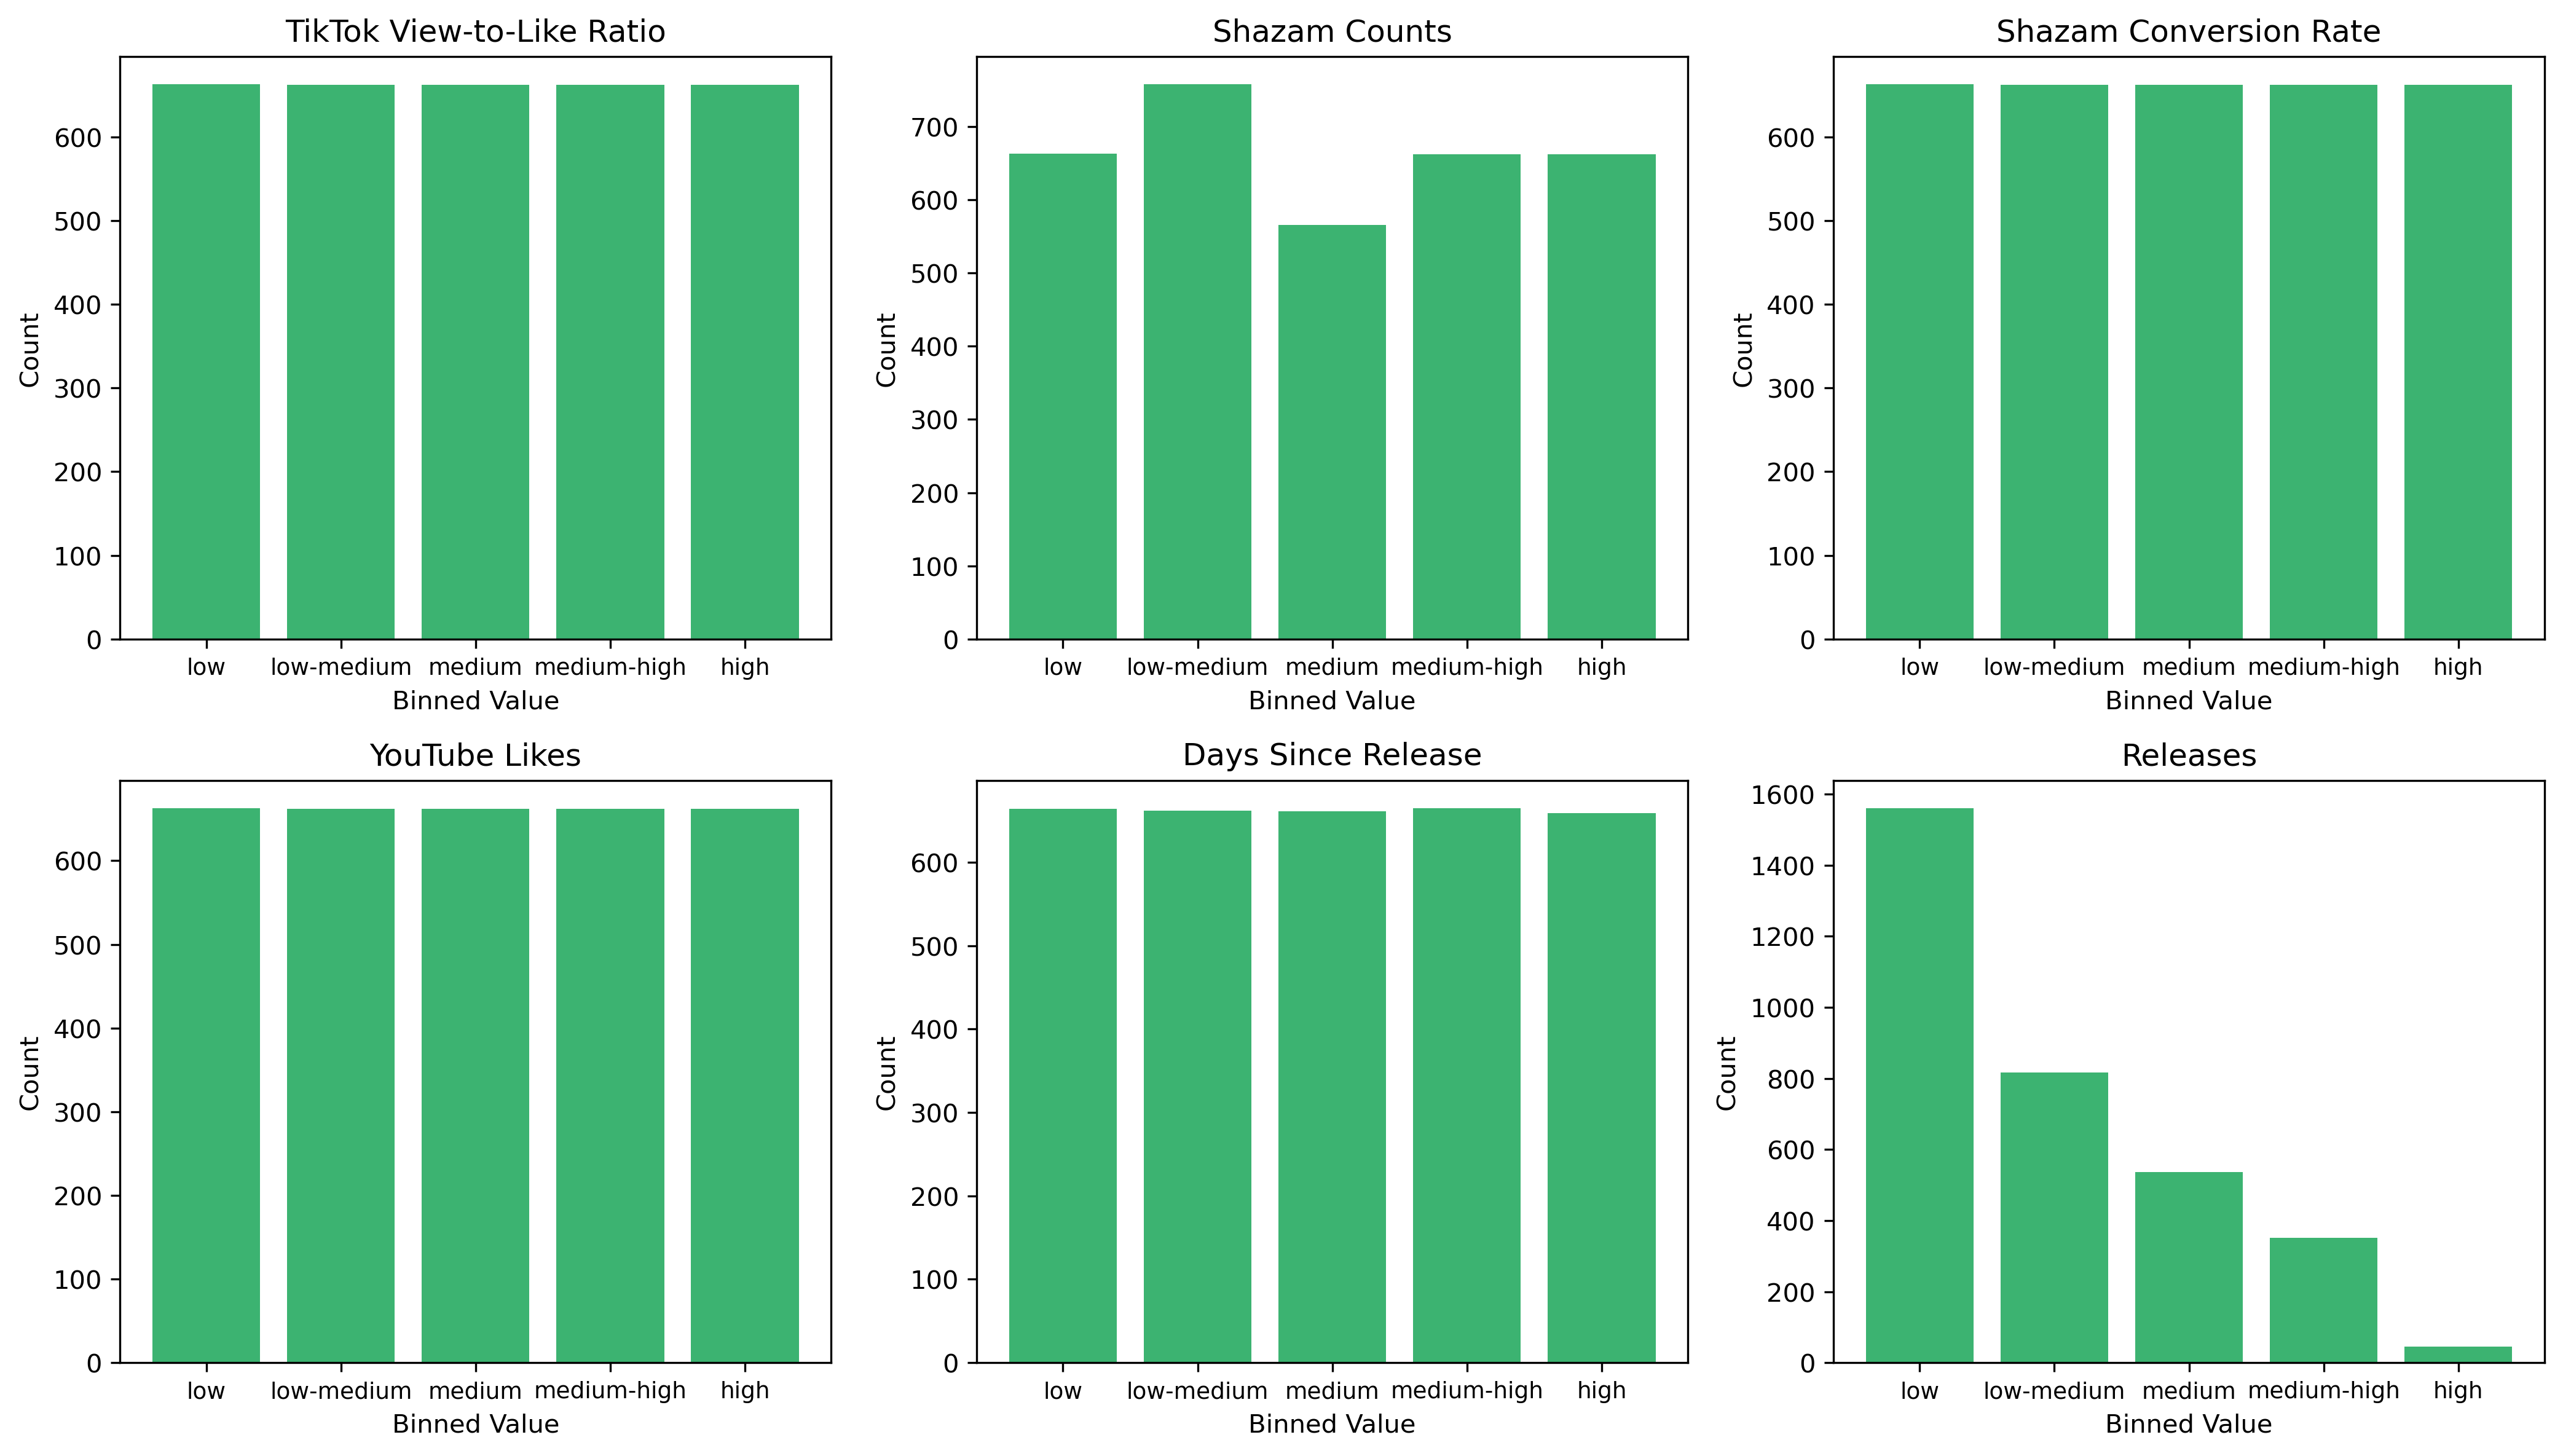

,low,low-medium,medium,medium-high,high,Label
0,3,1,1,1,0,1
1,2,1,1,2,0,1
2,1,1,2,1,1,1
3,0,2,1,1,2,1
4,1,1,2,0,2,1


In [4]:
import numpy as np

df_lr = df[['TikTok View-to-Like Ratio', # TikTok Views / (TikTok Likes + 1)
            'Shazam Counts',
            'Shazam Conversion Rate', # Shazam Counts / (YouTube Views + TikTok Views + 1)
            'YouTube Likes',
            'Days Since Release',
            'Releases',
            'Label']].copy()
df_lr.head()

my_corr_plotter(df_lr)

# 1. Define Logistic Regression dataset
df_lr['Releases'] = np.log1p(df_lr['Releases'])

df_lr_binned = my_count_binner(df_lr.drop('Label', axis=1))
df_lr_binned['Label'] = df_lr['Label']

my_bin_plotter(df_lr_binned.drop('Label', axis=1))

df_lr_collapsed = my_count_vectorizer(df_lr_binned)
df_lr_collapsed.head()

## Model Data

### Custom classes to reduce code repetition

See file at `./custom_model_prep.py` for the code.

In [5]:
from custom_model_prep import MySplitter, MyResults

### Logistic Regression

Training Data: (2648 rows ~80.0%)



,low,low-medium,medium,medium-high,high,Label
507,2,2,1,1,0,1
1338,0,3,2,1,0,1
2965,2,0,3,1,0,1
1479,0,3,1,1,1,1
839,1,0,3,2,0,1


Testing Data: (663 rows ~20.0%)



,low,low-medium,medium,medium-high,high,Label
1317,1,1,4,0,0,0
441,2,1,2,0,1,1
568,0,2,2,1,1,1
1639,0,0,4,1,1,1
357,1,1,1,3,0,1


Feature Names:
['low' 'low-medium' 'medium' 'medium-high' 'high']

Class Names:
['Low', 'High']


Accuracy: 0.7692
Precision: 0.8146
Recall:    0.8127
F1 Score:  0.8136


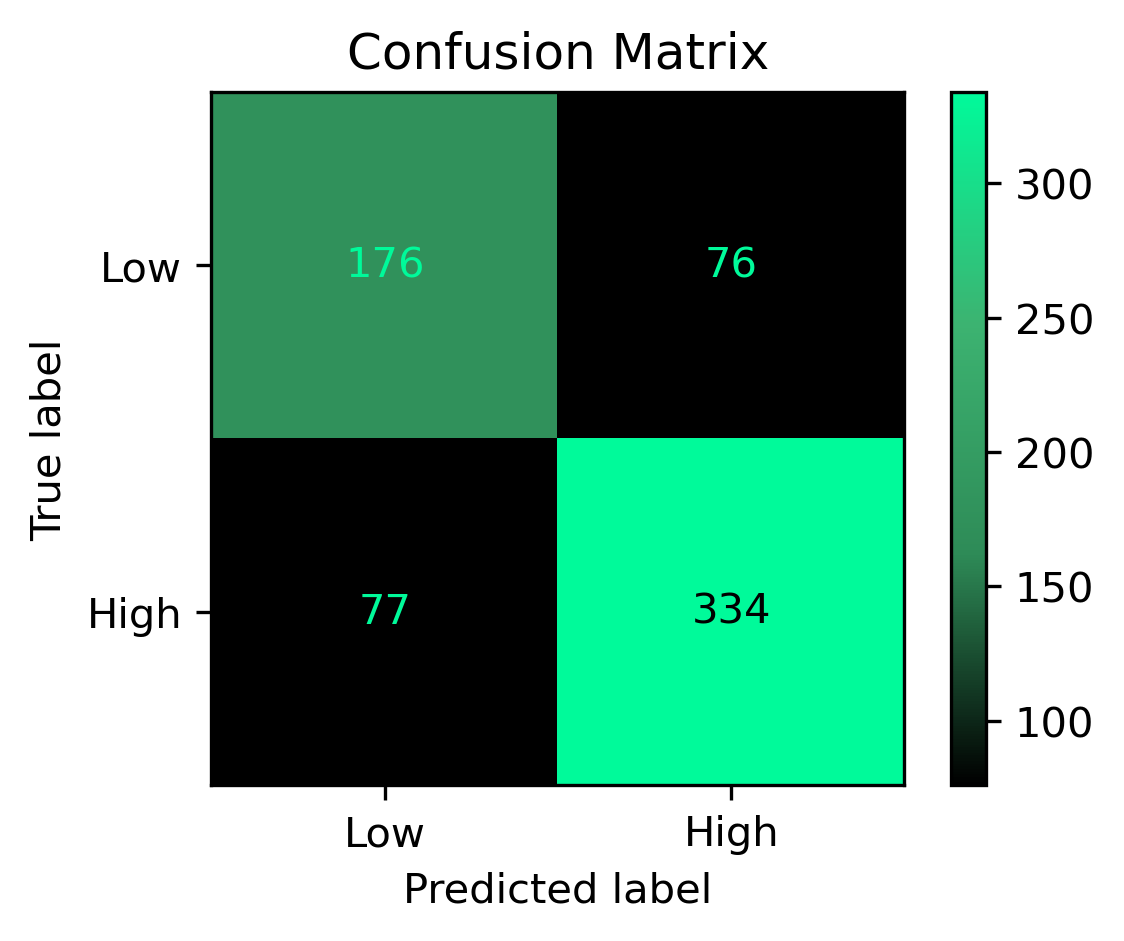

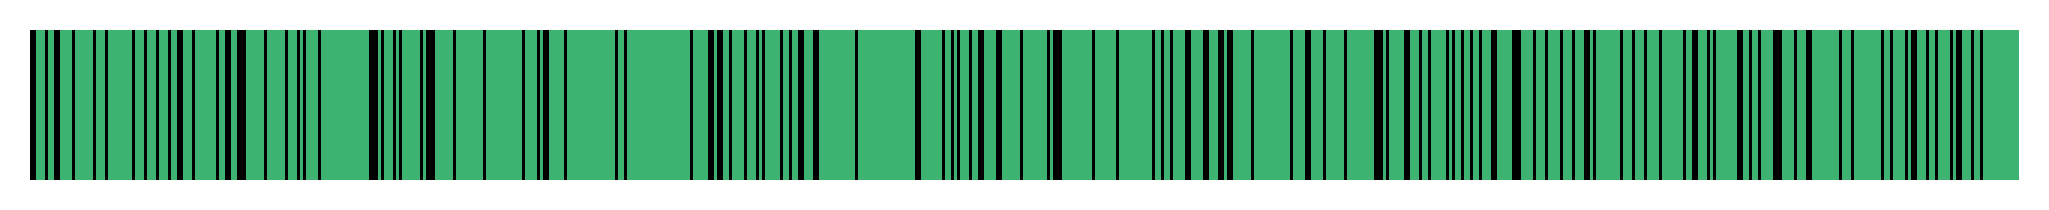

In [6]:
from sklearn import tree
from sklearn.linear_model import LogisticRegression

RSEED = 22


# 2. Splitting
splitter = MySplitter(df_lr_collapsed)

# -- Train-test split
train_df, test_df = splitter.train_test()
# -- X-y split
train_X, train_y, test_X, test_y, features, classes = splitter.x_y(train_df, test_df)


# 3. Normalization
# -- Logistic Regression does not need normalization


# 4. Training
LR = LogisticRegression(random_state=RSEED)
LR.fit(train_X, train_y)


# 5. Prediction
prediction = LR.predict(test_X)


# 6. Results
results = MyResults(test_y, prediction, classes)

# -- Via metrics
results.print_metrics()
# -- Via confusion matrix
results.plot_confusion_matrix()
# -- Via prediction barcode
results.plot_barcode()